# Experiment 1 — Stopping rule & completeness (Theorem 1)

**Goal (impl guide §13.1).** Show that when the agent stops, the realized **record recall**
exceeds the predicted `1 − ε`, and that the agent's unseen-mass estimate $\hat U_t$ is a valid
**upper bound** on the true unseen fraction throughout the run.

**What Theorem 1 says.** If the agent stops at the first step where $\hat U_t < \varepsilon$, then
with probability $\ge 1-\delta$ the set of discovered records covers at least a $1-\varepsilon$
fraction of the true record set $R$. $\hat U_t$ (design doc §2.4) combines the *singleton rate*
(records seen in exactly one source) with a *frontier-credit* term for searches not yet issued:

$$\hat U_t \;=\; \frac{r_t}{N_t} \;+\; \beta\,\frac{|F^{\text{active}}_t|}{N_t}.$$

**Pass criterion.** At the stopping step, recall $\ge 1-\varepsilon$ in at least $1-\delta$ of runs
(here $\delta=0.10$), and $\hat U_t \ge 1-\text{recall}_t$ at every step.

**This notebook is query-agnostic.** Everything below is generic except one `QuerySpec` block
(§1) and a ground-truth file. To run a different query, write a new `QuerySpec` and drop its
ground truth under `data/ground_truth/` — nothing else changes. We demonstrate it on the
**LeBron James 2018 NBA playoffs** query (an open-web query with a closed, authoritatively
reported answer: 22 games).

## 0. Setup

The repo's modules open prompt files by **relative** path (`prompts/relevance.txt`, …) and write
runs under `data/runs/`, so the working directory must be the **repo root**. We locate it (the
folder containing both `webagg/` and `prompts/`) regardless of where Jupyter was launched, `chdir`
there, and put it on `sys.path`. Only `FrontierState`/`Formulation` are imported now — they have no
API-client or file side-effects. The API clients are imported lazily later, so the **offline
self-test in §7 runs with no keys**.

A live run needs three keys in the repo's `.env`: `SERPER_API_KEY` (search), `OPENAI_API_KEY`
(the active `call_llm`), and `ANTHROPIC_API_KEY` (the repo's `webagg/llm.py` constructs an
Anthropic client at import time, so it must be present even though we use the OpenAI path).

In [1]:
import os, sys, json, uuid, re
from pathlib import Path
from dataclasses import dataclass
from collections import defaultdict
from datetime import datetime
from typing import Callable, Optional

%matplotlib inline

def _find_repo_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "webagg").is_dir() and (d / "prompts").is_dir():
            return d
    raise RuntimeError("Could not locate the webagg repo root (a folder with webagg/ and prompts/).")

REPO_ROOT = _find_repo_root(Path.cwd())
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print("repo root:", REPO_ROOT)

# Clean import: FrontierState already implements U_hat / singletons / active_frontier_size.
from webagg.frontier import FrontierState, Formulation

_missing = [k for k in ("SERPER_API_KEY", "OPENAI_API_KEY", "ANTHROPIC_API_KEY")
            if not os.environ.get(k)]
if _missing:
    print("WARNING: missing keys", _missing,
          "\n-> the live run (§8) will fail, but the offline self-test (§7) works without keys.")
else:
    print("all API keys present — live run enabled.")

repo root: D:\Projects\webagg
-> the live run (§8) will fail, but the offline self-test (§7) works without keys.


## 1. The query spec — the only query-specific part

A `QuerySpec` is everything the generic machinery needs to know about a query:

- `query` — the natural-language question (drives search + relevance).
- `ground_truth_file` — a JSON file under `data/ground_truth/` in the §12.2 schema.
- `record_kind` — a label handed to `propose_followups` (e.g. `"playoff_game"`).
- `key_field` — the field on each *extracted* record that identifies it (here `"date"`).
- `extract_system` — the extraction system prompt; it must return
  `{"records":[{<key_field>:…, …}]}`.
- `gt_key` — how to pull that same identifying key out of one *ground-truth* record.

The key idea: we identify a **record** (one game) by a stable attribute — the **game date** — so
that the discovery loop can count distinct games and measure recall. (More on why in §3.)

In [2]:
@dataclass
class QuerySpec:
    query: str
    ground_truth_file: str
    record_kind: str
    key_field: str
    extract_system: str
    gt_key: Callable[[dict], str]


# --- extraction prompt for the LeBron query: one record per game, keyed by ISO date ---
LEBRON_EXTRACT_SYS = (
    "You extract per-game scoring lines from a document, for a specific player and postseason.\n"
    'Return STRICT JSON only: {"records":[{"date":"YYYY-MM-DD","opponent":"team",'
    '"points":"NN","passage":"verbatim snippet"}]}\n'
    "Include a game ONLY if the document states the player's points for that game AND it is a "
    "2018 NBA PLAYOFF game (April-June 2018). Exclude regular-season games and other seasons. "
    "Convert every date to ISO YYYY-MM-DD; omit a game whose date is not determinable. "
    'Return {"records":[]} if there are none.'
)

LEBRON_SPEC = QuerySpec(
    query=("How many points did LeBron James score in each game of the 2018 NBA Playoffs, "
           "and what was his playoff points-per-game?"),
    ground_truth_file="lebron_2018_playoffs_ppg.json",
    record_kind="playoff_game",
    key_field="date",
    extract_system=LEBRON_EXTRACT_SYS,
    gt_key=lambda rec: rec["attributes"]["date"],
)

SPEC = LEBRON_SPEC            # <- swap this one line to run a different query
SPEC.query

'How many points did LeBron James score in each game of the 2018 NBA Playoffs, and what was his playoff points-per-game?'

## 2. Ground truth → the true record set $R$

We load the §12.2 ground-truth file and reduce it to the **set of true record keys** — the 22
game dates. Recall at any step is just $|\,\text{discovered keys} \cap R\,| / |R|$. Dates are
normalized through `normalize_date` so both sides match even if a page writes "April 25, 2018".

In [3]:
_MONTHS = {m.lower(): i for i, m in enumerate(
    ["", "January", "February", "March", "April", "May", "June",
     "July", "August", "September", "October", "November", "December"])}

def normalize_date(s: str) -> Optional[str]:
    """Best-effort string -> 'YYYY-MM-DD'. This is the key used to match games to ground truth."""
    if not s:
        return None
    s = s.strip()
    for fmt in ("%Y-%m-%d", "%m/%d/%Y", "%B %d, %Y", "%b %d, %Y", "%d %B %Y", "%d %b %Y"):
        try:
            return datetime.strptime(s, fmt).strftime("%Y-%m-%d")
        except ValueError:
            pass
    m = re.search(r"([A-Za-z]+)\.?\s+(\d{1,2}),?\s+(\d{4})", s)        # "Apr 25 2018"
    if m and m.group(1).lower() in _MONTHS:
        return f"{int(m.group(3)):04d}-{_MONTHS[m.group(1).lower()]:02d}-{int(m.group(2)):02d}"
    return s if re.fullmatch(r"\d{4}-\d{2}-\d{2}", s) else None

def load_ground_truth(spec: QuerySpec):
    path = REPO_ROOT / "data" / "ground_truth" / spec.ground_truth_file
    gt = json.loads(path.read_text())
    keys = {normalize_date(spec.gt_key(r)) for r in gt["records"]}
    keys.discard(None)
    return gt, keys

gt, gt_keys = load_ground_truth(SPEC)
print(f"|R| = {len(gt_keys)} true records (game dates)")
print("sample keys:", sorted(gt_keys)[:5], "...")

|R| = 22 true records (game dates)
sample keys: ['2018-04-15', '2018-04-18', '2018-04-20', '2018-04-22', '2018-04-25'] ...


## 3. Per-query extraction — and why we re-key records

The repo's `pipeline.run_query` keys records by `f"{entity_surface}|{record_kind}"`. That is a fine
proxy when there is ~one record per entity (the Alphabet-subsidiaries case), but here **all 22
games share the same entity** ("LeBron James") and kind ("playoff_game"), so that key would collapse
them into a *single* record — $N_t$ would never exceed 1 and recall would be unmeasurable.

So for this experiment a **record = one game**, identified by its **date**. `extract_records` asks
the repo's `call_llm` for one JSON record per game (`date`, `opponent`, `points`), and the loop keys
`covered_records` by the normalized date. This is the natural per-query analogue of "resolve funding
rounds by (amount, date)". The `points` value is carried for reporting but is **not** part of the
key — recall measures whether a game was *discovered*, independent of whether its points are exactly
right.

In [4]:
def extract_records(source, spec, *, max_tokens=8000, max_chars=6000):
    from webagg.llm import call_llm
    user = f"PLAYER/QUERY:\n{spec.query}\n\nDOCUMENT:\n{source.main_text[:max_chars]}"
    payload = call_llm(system=spec.extract_system, user=user, max_tokens=max_tokens)["payload"]
    return payload.get("records", [])

## 4. The instrumented discovery loop

`run_trajectory` mirrors `webagg.pipeline.run_query` — pick the highest-residual unissued
formulation, search, fetch, keep relevant sources, extract, and grow the frontier with deduped
follow-ups — with three deliberate differences:

1. **Record key.** `covered_records` is keyed by the **game-date key** (§3), not
   `entity_surface|record_kind`, so $N_t$ counts distinct games.
2. **Instrumentation.** Every step logs $\hat U_t,\ r_t,\ N_t,\ |F^{\text{active}}_t|$ and **recall
   vs ground truth** — the time series Experiment 1 plots.
3. **Injectable dependencies.** Search/fetch/relevance/extract/seed/follow-up come in a `deps`
   dict, so the *same* loop runs against the live Serper+LLM stack **or** an offline mock.

**Key efficiency point.** The discovery trajectory does **not** depend on $\varepsilon$ — $\varepsilon$
only decides *when to stop*. So we run each trial once to frontier exhaustion and then read off the
Theorem-1 stopping time $\tau_\varepsilon = \min\{t : \hat U_t < \varepsilon/2\}$ for *every*
$\varepsilon$ from that single trajectory. (`run_query` additionally requires the frontier to be
$\eta$-exhausted; that guard only makes stopping *more* conservative, i.e. recall can only go up, so
reading off the $\hat U_t$ threshold is the tight test of Theorem 1 — and it costs one trajectory
per trial instead of one per $(\varepsilon,\text{run})$.) A `max_formulations` guard bounds frontier
growth so a chatty follow-up model can't make the run unbounded (impl §13.1 pitfall: "runs never
stop").

In [5]:
def run_trajectory(spec, gt_keys, *, deps, eta=0.5, beta=1.0,
                   max_steps=45, max_formulations=40, k=8):
    search, fetch, relevant = deps["search"], deps["fetch"], deps["relevant"]
    extract, seed, followup  = deps["extract"], deps["seed"], deps["followup"]

    state = FrontierState()
    for f in seed(spec.query):                         # design doc Algorithm 1, line 1
        state.formulations[f.formulation_id] = f

    traj = []
    for step in range(1, max_steps + 1):
        unissued = [f for f in state.formulations.values() if not f.issued]
        if not unissued:                               # frontier exhausted -> done
            break
        f = max(unissued, key=lambda x: x.residual_yield)

        new = 0
        for r in search.search(f.query, k=k):          # issue the search
            src = fetch(r["url"], formulation_id=f.formulation_id)
            if src is None or not relevant(src, spec.query):
                continue
            for obs in extract(src, spec):             # one dict per game
                key = normalize_date(obs.get(spec.key_field))
                if key is None:
                    continue
                is_new = key not in state.covered_records
                state.covered_records[key].add(src.source_id)   # provenance per record
                if is_new:
                    new += 1
                    state.N += 1
                    if len(state.formulations) < max_formulations:   # grow frontier (deduped)
                        tried = {x.query for x in state.formulations.values()}
                        for nf in followup(spec.record_kind, key, already_tried=list(tried)):
                            if nf.query not in tried:
                                state.formulations[nf.formulation_id] = nf
                                tried.add(nf.query)

        f.issued = True
        f.realized_yield = new
        f.residual_yield = 0.0

        recall = len(set(state.covered_records) & gt_keys) / len(gt_keys) if gt_keys else 0.0
        traj.append(dict(step=step, U_hat=state.U_hat(beta=beta), r_t=state.singletons(),
                         N_t=state.N, frontier_active=state.active_frontier_size(eta),
                         recall=recall, unseen_true=1.0 - recall,
                         new_records=new, formulation=f.query))
    return traj


def stopping_time(traj, eps):
    """Theorem-1 stopping time: first step with U_hat < eps/2 (else the final step)."""
    for s in traj:
        if s["U_hat"] < eps / 2:
            return s["step"], s["recall"]
    return (traj[-1]["step"], traj[-1]["recall"]) if traj else (0, 0.0)


def run_trials(spec, gt_keys, *, deps, n_runs, **kw):
    return [run_trajectory(spec, gt_keys, deps=deps, **kw) for _ in range(n_runs)]


def pass_table(trajs, eps_values, delta=0.10):
    """Pass criterion (impl §13.1): recall >= 1-eps at the stop step in >= 1-delta of runs."""
    rows = []
    for eps in eps_values:
        taus = [stopping_time(t, eps) for t in trajs]
        recalls = [r for _, r in taus]
        ok = sum(r >= 1 - eps for r in recalls)
        rows.append(dict(eps=eps, target=round(1 - eps, 3),
                         mean_stop_step=round(sum(s for s, _ in taus) / len(taus), 1),
                         mean_recall_at_stop=round(sum(recalls) / len(recalls), 3),
                         runs_passing=f"{ok}/{len(trajs)}",
                         passes=bool(ok / len(trajs) >= 1 - delta)))
    return rows


def plot_stopping(trajs, eps_values, gt_size, out_path=None):
    """One panel per eps: U_hat (solid), true unseen 1-recall (dashed), eps/2 floor, stop step."""
    import matplotlib.pyplot as plt
    n = len(eps_values)
    fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(11, 7), squeeze=False)
    axes = axes.ravel()
    traj = trajs[0]                                    # representative run
    xs = [s["step"] for s in traj]
    for ax, eps in zip(axes, eps_values):
        tau, rec = stopping_time(traj, eps)
        ax.plot(xs, [s["U_hat"] for s in traj], "-o", ms=3, label=r"$\hat{U}_t$")
        ax.plot(xs, [s["unseen_true"] for s in traj], "--s", ms=3, label="true unseen (1-recall)")
        ax.axhline(eps / 2, color="red", ls=":", lw=1, label=r"$\varepsilon/2$")
        ax.axvline(tau, color="green", ls=":", lw=1)
        ax.set_title(fr"$\varepsilon$={eps}: stop @ step {tau}, recall={rec:.0%}")
        ax.set_xlabel("agent step"); ax.set_ylabel("unseen mass")
        ax.set_ylim(-0.05, 1.6); ax.legend(fontsize=7)
    for ax in axes[len(eps_values):]:
        ax.axis("off")
    fig.suptitle(f"Experiment 1 — stopping rule & completeness (|R|={gt_size})", y=1.0)
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, bbox_inches="tight", dpi=130)
    return fig

## 5. Experiment configuration

The impl guide runs five trials per $\varepsilon \in \{0.30, 0.20, 0.10, 0.05\}$. Because the
trajectory is $\varepsilon$-independent (§4), `N_RUNS` here is the number of trajectories — each
yields all four $\varepsilon$. **Cost knobs for the live run:** `N_RUNS`, `K` (results fetched per
search), `MAX_STEPS`, and `MAX_FORMULATIONS`. `RUN_LIVE` gates the paid API calls.

In [6]:
EPS_VALUES       = [0.30, 0.20, 0.10, 0.05]
DELTA            = 0.10
N_RUNS           = 5        # was 5
ETA              = 0.5
BETA             = 1.0
MAX_STEPS        = 25       # was 45
MAX_FORMULATIONS = 20       # was 40
K                = 5        # was 8 — this is the big one (fetches+extractions per step)
RUN_LIVE         = True
print("config set. RUN_LIVE =", RUN_LIVE)

config set. RUN_LIVE = True


## 6. Live dependencies (real Serper + repo modules)

`make_live_deps` wires the loop to the real stack: `SerperBackend` (live Serper), `fetch_url`
(httpx + trafilatura), `is_relevant` and our `extract_records` (repo `call_llm` / `gpt-5-nano`), and
the repo's `seed_formulations` / `propose_followups`. Imports are lazy so this cell is safe to define
even without keys.

In [7]:
def make_live_deps(spec):
    from webagg.search import SerperBackend
    from webagg.fetch import fetch_url
    from webagg.extract import is_relevant
    from webagg.pipeline import seed_formulations, propose_followups
    return dict(search=SerperBackend(), fetch=fetch_url, relevant=is_relevant,
                extract=extract_records, seed=seed_formulations, followup=propose_followups)

In [8]:
import json, hashlib
from types import SimpleNamespace

CACHE_DIR = REPO_ROOT / "data" / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _cache_path(kind, key):
    return CACHE_DIR / f"{kind}_{hashlib.sha256(key.encode()).hexdigest()[:16]}.json"

def _cache_get(kind, key, compute):
    p = _cache_path(kind, key)
    if p.exists():
        return json.loads(p.read_text())
    val = compute(); p.write_text(json.dumps(val)); return val

def make_cached_deps(spec, *, k=5):
    """Disk-cached, relevance-free deps. Re-runs/resumes reuse cached fetches+extractions;
    extraction failures are skipped (not cached) so a transient empty-response retries next run."""
    base = make_live_deps(spec)
    raw_search, raw_fetch = base["search"], base["fetch"]
    seed, followup = base["seed"], base["followup"]

    class CachedSearch:
        def search(self, query, k=k):
            return _cache_get("search", f"{query}||{k}", lambda: raw_search.search(query, k))

    def cached_fetch(url, formulation_id):
        p = _cache_path("fetch", url)
        if p.exists():
            d = json.loads(p.read_text())
        else:
            src = raw_fetch(url, formulation_id=formulation_id)
            d = None if src is None else {"main_text": src.main_text}
            if d:                                    # cache only successful fetches
                p.write_text(json.dumps(d))
        if not d:
            return None
        # Exp 1 only needs .source_id and .main_text; stable per-URL id keeps singleton counts consistent
        return SimpleNamespace(
            source_id="u_" + hashlib.sha256(url.encode()).hexdigest()[:14],
            url=url, main_text=d["main_text"])

    def cached_extract(source, spec):
        p = _cache_path("extract", f"{source.url}||{spec.query}")
        if p.exists():
            return json.loads(p.read_text())
        try:
            recs = extract_records(source, spec)
        except Exception as e:                       # empty/length, JSON drift, rate limit, ...
            print(f"  [skip] {type(e).__name__}: {source.url}")
            return []                                # skip; do NOT cache transient failures
        p.write_text(json.dumps(recs)); return recs

    return dict(search=CachedSearch(), fetch=cached_fetch,
                relevant=lambda s, q: True, extract=cached_extract,
                seed=seed, followup=followup)

## 7. Offline self-test (no API) — validate before spending budget

Impl §13.1's first pitfall is burning API budget while debugging. So we first exercise the *entire*
pipeline on a tiny synthetic corpus with **mock** search/fetch/extract — the same dependency-injection
discipline as the repo's `MockTransport` tests. Two mock "aggregator" pages give every game ≥2
sources (so singletons clear), per-series pages add redundancy, and follow-ups come from a small fixed
vocabulary so the frontier exhausts.

This cell runs for free and asserts the two invariants: $\hat U_t \ge 1-\text{recall}_t$ everywhere,
and recall $\ge 1-\varepsilon$ at every $\tau_\varepsilon$.

trajectory (run 0):
  step  1  U_hat=1.571  r= 7 N= 7  |F_active|=4  recall=0.32
  step  2  U_hat=1.286  r=14 N=14  |F_active|=4  recall=0.64
  step  3  U_hat=0.591  r= 8 N=22  |F_active|=5  recall=1.00
  step  4  U_hat=0.182  r= 0 N=22  |F_active|=4  recall=1.00
  step  5  U_hat=0.136  r= 0 N=22  |F_active|=3  recall=1.00
  step  6  U_hat=0.091  r= 0 N=22  |F_active|=2  recall=1.00
  step  7  U_hat=0.045  r= 0 N=22  |F_active|=1  recall=1.00
  step  8  U_hat=0.000  r= 0 N=22  |F_active|=0  recall=1.00

self-test OK: U_hat upper-bounds true unseen, and recall >= 1-eps at every stop.


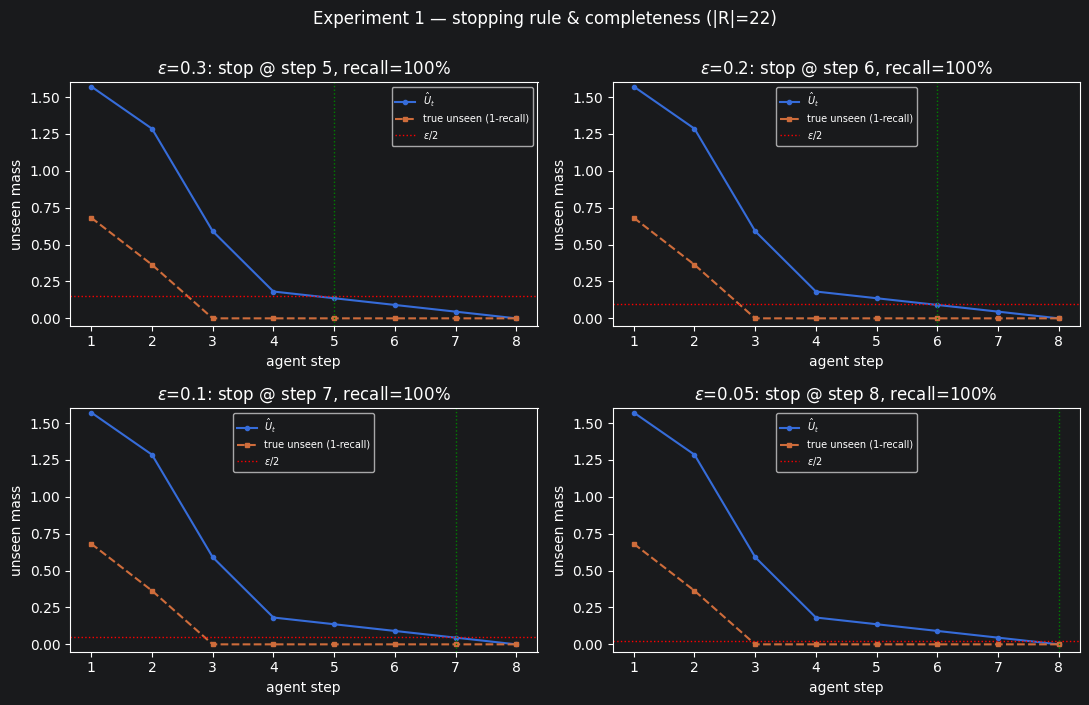

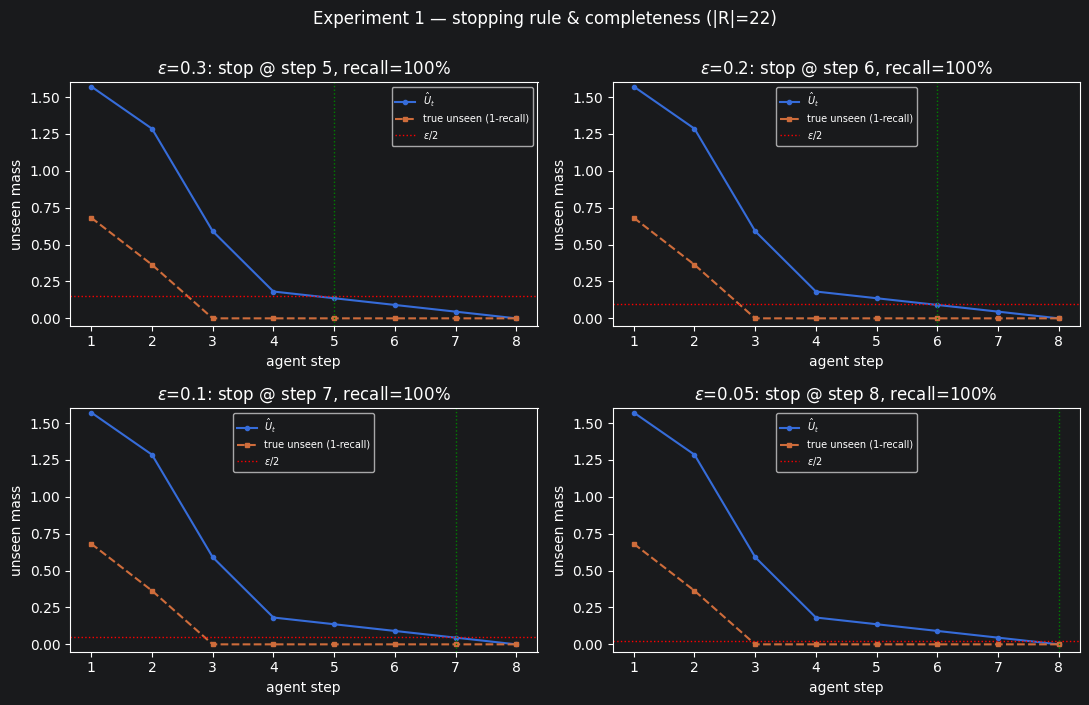

In [9]:
from types import SimpleNamespace

def make_mock_deps(gt):
    by_date = {r["attributes"]["date"]: r["attributes"] for r in gt["records"]}
    ser = defaultdict(list)
    for d, a in by_date.items():
        ser[a["opponent"]].append(d)
    DOCS = {                                            # mock source_id -> dates it covers
        "boxref_all":   set(by_date),                   # aggregator A (all games)
        "statmuse_all": set(by_date),                   # aggregator B (all games)
        "pg_pacers":    set(ser["Indiana Pacers"]),
        "pg_raptors":   set(ser["Toronto Raptors"]),
        "pg_celtics":   set(ser["Boston Celtics"]),
        "pg_warriors":  set(ser["Golden State Warriors"]),
    }
    def mock_search(query, k=10):
        q = query.lower()
        if   "stat" in q:                                doc = "statmuse_all"
        elif "box score" in q or "complete" in q:        doc = "boxref_all"
        elif "pacers" in q or "first round" in q:        doc = "pg_pacers"
        elif "raptors" in q or "semifinal" in q:         doc = "pg_raptors"
        elif "celtics" in q or "conference finals" in q: doc = "pg_celtics"
        elif "warriors" in q or "nba finals" in q:       doc = "pg_warriors"
        elif "playoff" in q:                             doc = "boxref_all"
        else:                                            return []
        return [{"url": f"mock://{doc}", "title": doc, "snippet": ""}]
    def mock_fetch(url, formulation_id):
        doc = url.split("//", 1)[1]                      # source_id == doc (same page = one source)
        text = "; ".join(f"{by_date[d]['opponent']} {d}: {by_date[d]['points']} pts"
                         for d in sorted(DOCS[doc]))
        return SimpleNamespace(source_id=doc, url=url, main_text=text, formulation_id=formulation_id)
    def mock_relevant(src, query):
        return True
    def mock_extract(src, spec):
        return [{"date": d, "opponent": by_date[d]["opponent"], "points": by_date[d]["points"]}
                for d in sorted(DOCS[src.source_id])]
    def _f(q, y):
        return Formulation(formulation_id=str(uuid.uuid4())[:8], query=q, expected_yield=float(y))
    def mock_seed(query):                               # partial start: Pacers + Celtics (14/22)
        return [_f("lebron 2018 first round pacers", 5),
                _f("lebron 2018 conference finals celtics", 5)]
    def mock_followup(record_kind, key, already_tried):
        opp = by_date[key]["opponent"].split()[-1].lower()
        return [_f("lebron 2018 complete playoff box scores", 4),   # -> boxref_all
                _f("lebron 2018 playoff per-game stats", 4),        # -> statmuse_all
                _f(f"lebron 2018 {opp} series points", 3)]          # -> per-series redundancy
    return dict(search=SimpleNamespace(search=mock_search), fetch=mock_fetch, relevant=mock_relevant,
                extract=mock_extract, seed=mock_seed, followup=mock_followup)


selftest_trajs = run_trials(SPEC, gt_keys, deps=make_mock_deps(gt), n_runs=3,
                            eta=ETA, beta=BETA, max_steps=MAX_STEPS,
                            max_formulations=MAX_FORMULATIONS, k=K)

print("trajectory (run 0):")
for s in selftest_trajs[0]:
    print(f"  step {s['step']:>2}  U_hat={s['U_hat']:.3f}  r={s['r_t']:>2} N={s['N_t']:>2}"
          f"  |F_active|={s['frontier_active']}  recall={s['recall']:.2f}")

for traj in selftest_trajs:
    for s in traj:
        assert s["U_hat"] + 1e-9 >= s["unseen_true"], "U_hat must upper-bound true unseen"
    for eps in EPS_VALUES:
        _, rec = stopping_time(traj, eps)
        assert rec >= 1 - eps - 1e-9, (eps, rec)
print("\nself-test OK: U_hat upper-bounds true unseen, and recall >= 1-eps at every stop.")

plot_stopping(selftest_trajs, EPS_VALUES, len(gt_keys),
              out_path=REPO_ROOT / "figures" / "exp1_selftest.png")

## 8. The live experiment

Set `RUN_LIVE = True` in §5 to run for real. Each trial issues live Serper searches and calls
`gpt-5-nano` for relevance/extraction/follow-ups, running to frontier exhaustion. Trajectories are
saved to `data/runs/exp1_trajectories.json` so the analysis below can be re-run without paying again.

*If every run stops at step 1*, the seed formulations are too narrow (impl §13.1). *If runs never
stop*, the follow-up model is emitting near-duplicate queries — lower `MAX_FORMULATIONS` or tighten
dedup.

In [10]:
import time
live_trajs = []
ckpt = REPO_ROOT / "data" / "runs" / "exp1_trajectories.json"
ckpt.parent.mkdir(parents=True, exist_ok=True)

if RUN_LIVE:
    deps = make_cached_deps(SPEC, k=K)               # cached + relevance-free
    for i in range(N_RUNS):
        t0 = time.time()
        traj = run_trajectory(SPEC, gt_keys, deps=deps, eta=ETA, beta=BETA,
                              max_steps=MAX_STEPS, max_formulations=MAX_FORMULATIONS, k=K)
        live_trajs.append(traj)
        ckpt.write_text(json.dumps(live_trajs))      # checkpoint after EACH run
        rec = traj[-1]["recall"] if traj else 0.0
        print(f"run {i+1}/{N_RUNS}: {len(traj)} steps, recall->{rec:.2f}, {time.time()-t0:.0f}s")
    print(f"done -> {ckpt}")
else:
    print("RUN_LIVE=False — using the offline self-test trajectories below.")

Exception ignored in: <function SetBase.__del__ at 0x000002389435E340>
Traceback (most recent call last):
  File "C:\Users\WANG ZHE\AppData\Local\Programs\Python\Python311\Lib\site-packages\regex\_regex_core.py", line 3817, in __del__
    def __del__(self):

KeyboardInterrupt: 


KeyboardInterrupt: 

## 9. Results — stopping curve & pass criterion

The figure is saved to `figures/exp1_stopping.pdf`. Read each panel as: the solid line ($\hat U_t$)
should stay **above** the dashed line (true unseen $=1-\text{recall}$) everywhere — the upper-bound
property — and the green stop line marks $\tau_\varepsilon$, where recall should already be
$\ge 1-\varepsilon$. The table reports the formal pass criterion across runs.

In [ ]:
import pandas as pd
from IPython.display import display

trajs = live_trajs if (RUN_LIVE and live_trajs) else selftest_trajs
source = "LIVE" if (RUN_LIVE and live_trajs) else "OFFLINE self-test"
print(f"results from: {source}  ({len(trajs)} trajectories, |R|={len(gt_keys)})")

fig = plot_stopping(trajs, EPS_VALUES, len(gt_keys),
                    out_path=REPO_ROOT / "figures" / "exp1_stopping.pdf")

df = pd.DataFrame(pass_table(trajs, EPS_VALUES, delta=DELTA))
display(df)
print("\nPASS" if df["passes"].all() else "\nFAIL", "— recall >= 1-eps at stop in >= 1-delta of runs")
fig

## 10. Reusing this notebook for another query

1. **Write a ground-truth file** in the §12.2 schema and save it under `data/ground_truth/`. The
   set of true record keys is whatever uniquely identifies a record for your query.
2. **Write a `QuerySpec`** (§1): the `query`, the `ground_truth_file`, a `record_kind`, the
   `key_field` your extraction emits, an `extract_system` prompt returning
   `{"records":[{<key_field>:…}]}`, and a `gt_key` that pulls the same key from a ground-truth
   record. Set `SPEC = your_spec`.
3. **Run all cells.** The discovery loop, $\hat U_t$, the stopping rule, recall scoring, the
   self-test, and the plots are all query-agnostic.

For example, the Alphabet-subsidiaries query keys a record by `(subsidiary, round_type)` instead of
a date; the `extract_system` would return one record per funding round and `gt_key` would build that
pair from each ground-truth record. Everything else is unchanged.